In [1]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import glob, os
import SFI
import SFI.OLI_bases
import jax.numpy as jnp
from jax import random
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import pickle
from scipy.spatial.distance import jensenshannon


In [2]:
def get_experimentID_fightbouts(path):

    tracking_folder = os.path.dirname(path)

    loadpaths = glob.glob(os.path.join(tracking_folder, "*results.h5"))
    loadpaths.sort()

    expNames = [os.path.basename(p)[:23] for p in loadpaths]

    target_expName = os.path.basename(path)[:23]
    expIdx = expNames.index(target_expName)

    fightbout_path = os.path.join(tracking_folder, "fightBouts.h5")

    with h5py.File(fightbout_path, "r") as j:
        fb = j["fight_bout_info_noDurThresh"][:]

    fightbouts = fb[fb[:, 0].astype(int) == expIdx]

    return expIdx, fightbouts
EXP_id , fightbout = get_experimentID_fightbouts("/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_153857_tracking_results.h5")
print(fightbout)

[[     2  31500 175400 143900]
 [     2 301300 319600  18300]]


In [51]:
def prepare_data(path,fightnumber = 0,infight =True):
    "Prepare the data make it ready to calculate dpp,theta1 and theta2"
    "if infight = True return data with only the infight bouts otherwise it returns total trajectory  "

    path = path
    f = h5py.File(path, "r")

    X = f["tracks_3D_smooth"][:]
    EXP_id , fightbout = get_experimentID_fightbouts(path)
    if infight == True and fightbout.size > 0:
        X_coordinates = X[fightbout[fightnumber,1]:fightbout[fightnumber,2],:,:,:]
    else:
        X_coordinates = X.copy()
    return X_coordinates,fightbout[fightnumber]

path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_181614_tracking_results.h5"
X_coordinates_3, fightbout = prepare_data(path,fightnumber = 0,infight =True)
print(fightbout)
def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def calculate_theta(fish0,fish1):
    vector_fish0 = (fish0[:,0,:] - fish0[:,1,:]) # difference in heading of head and pec
    orientation_fish0 = vector_fish0/np.linalg.norm(vector_fish0, axis=1, keepdims=True)

    theta0 = np.arctan2(orientation_fish0[:, 1],  orientation_fish0[:, 0])

    r_01 = fish1[:,1,:] - fish0[:,1,:] 
    phi_01 = np.arctan2(r_01[:,1],r_01[:,0]) #dy,dx

    theta0 = np.arctan2(vector_fish0[:, 1], vector_fish0[:, 0])
    psi_01 = phi_01 - theta0
    psi_01 = wrap_pi(psi_01) # wrap interval from -pi to pi
    return psi_01

[     3 331300 436400 105100]


In [4]:
def calculate_variables(coordinates_cleaned):
    "input are the coordinates and returns dpp,theta_i and theta_j"

    fish_i = coordinates_cleaned[:,0,:,:]
    fish_j = coordinates_cleaned[:,1,:,:]

    pec_fish_i = coordinates_cleaned[:,0,1,:]
    pec_fish_j = coordinates_cleaned[:,1,1,:]

    d_pp = np.linalg.norm((pec_fish_j-pec_fish_i), axis=1) 
    
    theta_i = calculate_theta(fish_i,fish_j)
    theta_j = calculate_theta(fish_j,fish_i)

    return d_pp, theta_i,theta_j
    
def clean_data(d_pp,theta_i,theta_j):
    mask = (np.isfinite(d_pp) &np.isfinite(theta_i) & np.isfinite(theta_j))
    return d_pp[mask],theta_i[mask],theta_j[mask]


def Build_segmented_data(dpp,theta1,theta2):
    Valid = (np.isfinite(dpp) &np.isfinite(theta1) & np.isfinite(theta2))
    valid_idx = np.where(Valid)[0]

    X_list = []
    time_list = []
    segid_list = []
    seg_ranges = []
    start = 0
    t_offset = 0
    seg_id = 0

    for k in range(1, len(valid_idx) + 1):
        if k == len(valid_idx) or valid_idx[k] != valid_idx[k - 1] + 1: # if there is the end of trajectory or a hole 

            seg_idx = valid_idx[start:k]

            if len(seg_idx) > 5:
                D_seg = dpp[seg_idx]
                th1_seg = np.unwrap(theta1[seg_idx])
                th2_seg = np.unwrap(theta2[seg_idx])

                X_list.append(np.column_stack([D_seg, th1_seg, th2_seg]))
                time_list.append(np.arange(len(seg_idx)) + t_offset)
                segid_list.append(np.full(len(seg_idx), seg_id, dtype=int))
                seg_ranges.append((seg_idx[0], seg_idx[-1]))

                t_offset += len(seg_idx) + 1
                seg_id += 1

            start = k

    X = np.vstack(X_list)
    time_idx = np.concatenate(time_list)
    segment_ids = np.concatenate(segid_list)
    return X, time_idx, segment_ids, seg_ranges

def subsample_random_segments(X, segment_ids, fraction=0.85):
    np.random.seed(5)
    unique_segments = np.unique(segment_ids)
    n_keep = int(fraction * len(unique_segments))
    keep_seg = np.random.choice(unique_segments,size=n_keep,replace= False)

    X_list = []
    time_list = []
    t_offset = 0
    for seg in keep_seg:
        indices = np.where(segment_ids == seg)[0]
        X_seg = X[indices]
        X_list.append(X_seg)
        time_list.append(np.arange(len(X_seg)) + t_offset)
        t_offset += len(X_seg) + 1

    X_new = np.vstack(X_list)
    time_idx_new = np.concatenate(time_list)
    return X_new, time_idx_new

def Run_Force_inference(X,time_idx,K,M,lam):
    traj = SFI.StochasticTrajectoryData(X, time_idx, 0.01)
    poly_1d,poly_describe = SFI.OLI_bases.polynomial_basis(dim=1,order=K)
    fourier1d_F1 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center= jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    fourier1d_F2 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center = jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    
    def radial_basis(D):
        """
                [
        [0.3, 1.0, 5.0],
        [0.5, 1.5, 6.0],
        [0.5, 1.5, 10.0],
        [0.7, 2.0, 8.0],
        [1.0, 3.0, 10.0],
        ]"""
        #lam = jnp.array([0.8,2.5, 6.0]) good for second experiment
        #lam = jnp.array([0.7,2.7, 7.0]) #good for second experiment
        #lam = jnp.array([0.5, 1.0,5.0]) good for frist 
        #p_exp = jnp.exp(-D /lam)

        return jnp.exp(-D / lam)#p_exp #jnp.concatenate([p_poly,p_exp])

    def C_func(x):
        D  = x[0]
        th1 = x[1]
        th2 = x[2]

        p  = poly_1d(jnp.array([D]))
        p = radial_basis(D)      
        f1 = fourier1d_F1(jnp.array([th1]))
        f2 = fourier1d_F2(jnp.array([th2]))  
        triple = jnp.einsum('i,j,k->ijk', p, f1[1:], f2[1:]).reshape(-1)
        
        phi = jnp.concatenate([
        p, f1, f2, jnp.outer(p, f1[1:]).reshape(-1),jnp.outer(f2[1:], f1[1:]).reshape(-1),
        jnp.outer(p, f2[1:]).reshape(-1),
        triple], axis=0)
        return phi 
    
    S = SFI.OverdampedLangevinInference(traj)
    S.compute_diffusion_constant(method="MSD")
    (funcs_and_grad, descriptor) = SFI.OLI_bases.basis_selector(
        {"type": "custom_scalar", "functions": C_func},
        dimension=3,
        output="vector"
    )
  
    basis_F, grad_F = funcs_and_grad
    S.infer_force_linear(basis_linear=basis_F, basis_linear_gradient=grad_F)
    #S.sparsify_force()
    S.compute_force_error() 
    S.print_report()
    return S, descriptor


(170900, 2, 3, 3)
(170900,)


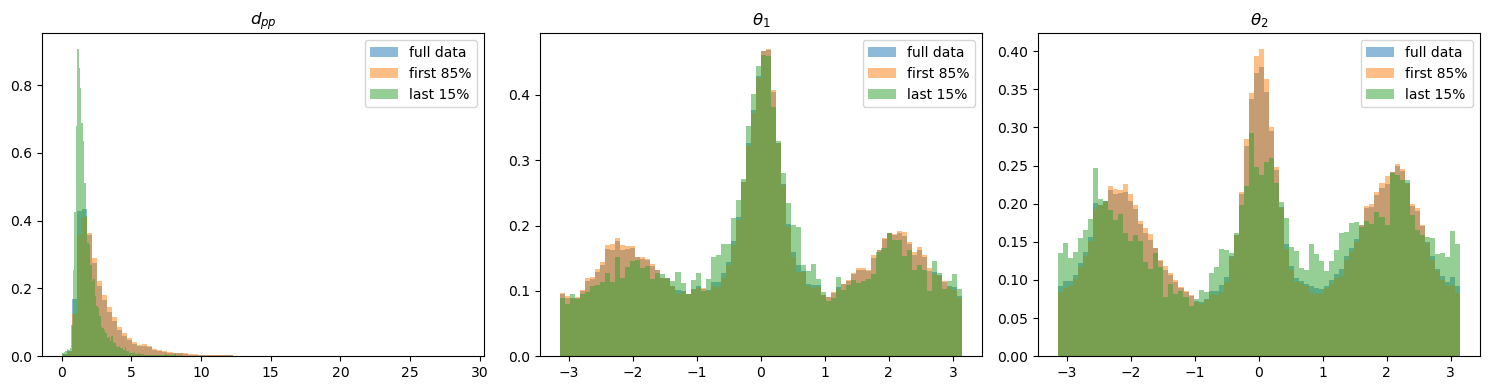

In [269]:
path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200525_161602_tracking_results.h5"
X_coordinates, fightbout = prepare_data(path,0,True)
print(X_coordinates.shape)
dpp,theta1,theta2 = calculate_variables(X_coordinates[:,:,:,:])
print(dpp.shape)

ig, axs = plt.subplots(1, 3, figsize=(15,4))
d_pp_c, theta_i_c, theta_j_c = clean_data(dpp, theta1, theta2)
N = len(d_pp_c)

dpp_85 = d_pp_c[:int(0.85*N)]
dpp_15 = d_pp_c[int(0.85*N):]

thetai_85 = theta_i_c[:int(0.85*N)]
thetai_15 = theta_i_c[int(0.85*N):]

thetaj_85 = theta_j_c[:int(0.85*N)]
thetaj_15 = theta_j_c[int(0.85*N):]

axs[0].hist(d_pp_c, bins=80, alpha=0.5,density = True, label='full data')
axs[0].hist(dpp_85, bins=80, alpha=0.5, density = True,label='first 85%')
axs[0].hist(dpp_15, bins=80, alpha=0.5,density = True, label='last 15%')

axs[0].set_title(r'$d_{pp}$')
axs[0].legend()

# Theta 1
axs[1].hist(theta_i_c, bins=80, alpha=0.5, density = True,label='full data')
axs[1].hist(thetai_85, bins=80, alpha=0.5,density = True, label='first 85%')
axs[1].hist(thetai_15, bins=80, alpha=0.5, density = True,label='last 15%')

axs[1].set_title(r"$\theta_1$")
axs[1].legend()

# Theta 2
axs[2].hist(theta_j_c, bins=80, alpha=0.5,density = True, label='full data')
axs[2].hist(thetaj_85, bins=80, alpha=0.5, density = True,label='first 85%')
axs[2].hist(thetaj_15, bins=80, alpha=0.5,density = True, label='last 15%')

axs[2].set_title(r"$\theta_2$")
axs[2].legend()

plt.tight_layout()
plt.show()

(517000, 2, 3, 3)
(517000,)
(87000,)


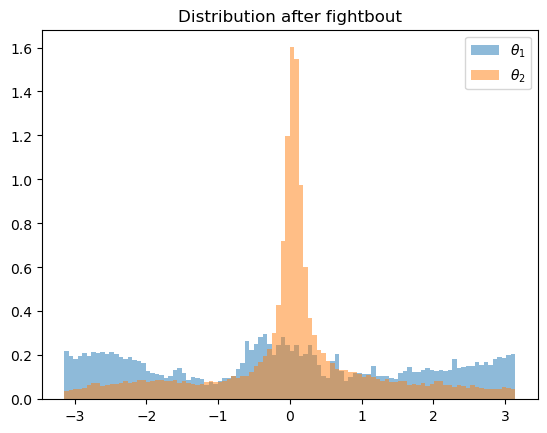

In [61]:
X_coordinates_3, fightbout = prepare_data(path,0,False)
print(X_coordinates_3.shape)
dpp_3,theta1_3,theta2_3 = calculate_variables(X_coordinates_3[:,:,:,:])
print(dpp_3.shape)
dpp_between,theta1_between,theta2_between = dpp_3[430000:],theta1_3[430000:],theta2_3[430000:]
print(dpp_between.shape)
plt.hist(theta1_between,alpha  =0.5,label = r'$\theta_1$',bins = 100,density = True)
plt.hist(theta2_between,alpha =0.5,label = r'$\theta_2$',bins = 100,density = True)
plt.title('Distribution after fightbout')
plt.legend()

### Choose the file and if you want total or only in fight

In [62]:
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_153857_tracking_results.h5"
#d_pp,theta_i,theta_j = calculate_variables(prepare_data(path,True))
#path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200525_161602_tracking_results.h5"
path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_181614_tracking_results.h5"

X_coordinates_3, fightbout_3 = prepare_data(path,0,infight=True)
dpp_3,theta1_3,theta2_3 = calculate_variables(X_coordinates_3[:,:,:,:])
print(dpp_3.shape)
X_3, time_idx, segment_ids, seg_ranges = Build_segmented_data(dpp_3, theta1_3, theta2_3)

#X, t = subsample_random_segments(X, segment_ids, fraction=1)
#S85, descriptor = Run_Force_inference(X, t, K=3, M=4,lam = jnp.array([0.77, 2.8, 7.1]))
n = int(1* len(X_3))


X_50_3 = X_3[:n]
t_50_3 = time_idx[:n]
print(len(X_50_3), len(t_50_3))

S_50, descriptor = Run_Force_inference(
    X_50_3, t_50_3,
    K=3, M=4,
    lam=jnp.array([0.77, 2.8, 7.1])
)

#N = len(d_pp)
#dpp_half,thetai_half,thetaj_half = d_pp[:int(N)],theta_i[:int( N)], theta_j[:int( N)]
#X, time_idx,_,_ = Build_segmented_data(d_pp, theta_i, theta_j)
#S_half, descriptor = Run_Force_inference(X,time_idx, K=2, M=3)

(105100,)
99931 99931
Measurement noise trace: -0.04074018448591232.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -0.04074018448591232). 

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[ 0.69487184 -0.00284266  0.02081118]
 [-0.00284266  1.270459    0.35177976]
 [ 0.02081118  0.35177976  1.268662  ]]
Measurement noise tensor:
 [[-1.1330015e-02 -4.2388619e-05 -2.7082083e-04]
 [-4.2388583e-05 -1.4585102e-02 -3.0382895e-03]
 [-2.7082080e-04 -3.0382890e-03 -1.4825070e-02]]
Force estimated information: 29363.369140625
Force: estimated normalized mean squared error (sampling only): 0.04352395609021187
Force model:
 +24.63 (±1.229) b₀ -18 (±0.2767) b₁ +16.14 (±0.1258) b₂ +3.08 (±0.07124) b₃ -8.338 (±0.1485) b₄ +0.06748 (±0.1666) b₅ +1.004 (±0.1628) b₆ +0.5066 (±0.1794) b₇ -0.5509 (±0.1872) b₈ +0.08483 (±0.1848) b₉ +0.684 (±0.1904) b₁₀ +0.4049 (±0.2029) b₁₁ -6.43 (±0.07124) b₁₂ -11.22 (±0.1574) b₁₃ -4.13 (±0.157) b₁₄ -0.

In [63]:
def Simulation(S_model,x0,dt,N_steps,key):
    Diffusion = np.array(S_model.diffusion_average)
    L = jnp.linalg.cholesky(Diffusion)
    x = jnp.array(x0)
    xs = []
    for _ in range(N_steps):
        xs.append(x)
        drift = S_model.force_ansatz(x[None, :])[0] 
        key, subkey = random.split(key)
        xi = random.normal(subkey, (3,))

        x = x + drift * dt + jnp.sqrt(2*dt) *  (L @ xi)
        
        x = x.at[0].set(jnp.clip(x[0], 0.0, 35))  
        x = x.at[1].set(wrap_pi(x[1]))
        x = x.at[2].set(wrap_pi(x[2]))

    return jnp.stack(xs), key
d_pp_c, theta_i_c, theta_j_c = clean_data(dpp, theta1, theta2)

t0 = np.random.randint(0, len(d_pp_c))
x0 = [d_pp_c[t0],theta_i_c[t0],theta_j_c[t0]]

key = random.PRNGKey(0)
traj_sim, key = Simulation(S_50, x0, dt=0.01, N_steps=500000, key=key)

In [321]:
def js_score(real, sim, bins, range_):
    hist_real, bin_edges = np.histogram(real, bins=bins, range=range_)
    hist_sim, _ = np.histogram(sim, bins=bin_edges, range=range_)

    p = hist_real / np.sum(hist_real)
    q = hist_sim / np.sum(hist_sim)

    return jensenshannon(p, q)


def average_js_score(real_dpp, real_t1, real_t2, traj_sim):
    score_dpp = js_score(real_dpp, np.array(traj_sim[:, 0]), bins=50, range_=(0, 20))
    score_t1  = js_score(real_t1,  np.array(traj_sim[:, 1]), bins=50, range_=(-np.pi, np.pi))
    score_t2  = js_score(real_t2,  np.array(traj_sim[:, 2]), bins=50, range_=(-np.pi, np.pi))
    return (score_dpp + score_t1 + score_t2) / 3


In [315]:
lambda_list = [
    jnp.array([0.72, 2.75, 7.0]),
    jnp.array([0.75, 2.8 , 7.2]),
    jnp.array([0.78, 2.85, 7.3]),
    jnp.array([0.80, 2.9 , 7.4]),
    jnp.array([0.77, 2.8 , 7.1]),
]

d_pp_c, theta_i_c, theta_j_c = clean_data(dpp, theta1, theta2)

t0 = np.random.randint(0, len(d_pp_c))
x0 = [d_pp_c[t0], theta_i_c[t0], theta_j_c[t0]]

results = []

for i, lam in enumerate(lambda_list):
    print(f"\nTesting lambda set {i+1}: {lam}")

    S_model, descriptor = Run_Force_inference(X, t, K=2, M=3, lam=lam)

    key = random.PRNGKey(i)
    traj_sim, key = Simulation(S_model, x0, dt=0.01, N_steps=500000, key=key)

    score = average_js_score(d_pp_c, theta_i_c, theta_j_c, traj_sim)

    results.append((np.array(lam), score))
    print("average JS score =", score)
    
results_sorted = sorted(results, key=lambda x: x[1])

print("\nBest lambda sets:")
for lam, score in results_sorted:
    print("lam =", lam, " score =", score)


Testing lambda set 1: [0.72 2.75 7.  ]
Measurement noise trace: -0.034152839332818985.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -0.034152839332818985). 

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[ 5.9410793e-01 -6.3742010e-04 -4.2141806e-03]
 [-6.3742010e-04  1.2199098e+00  3.1418625e-01]
 [-4.2141806e-03  3.1418625e-01  1.3181276e+00]]
Measurement noise tensor:
 [[-0.00917336 -0.00027212  0.00011783]
 [-0.00027212 -0.01216163 -0.00375492]
 [ 0.00011783 -0.00375492 -0.01281785]]
Force estimated information: 29140.04296875
Force: estimated normalized mean squared error (sampling only): 0.02916959673166275
Force model:
 +28.27 (±0.9928) b₀ -22.25 (±0.289) b₁ +17.86 (±0.138) b₂ -0.8815 (±0.08206) b₃ -10.2 (±0.2084) b₄ -2.338 (±0.2089) b₅ +1.057 (±0.2217) b₆ +1.941 (±0.2284) b₇ -0.811 (±0.2144) b₈ +0.3853 (±0.2261) b₉ -3.19 (±0.08206) b₁₀ -6.366 (±0.2167) b₁₁ -0.1436 (±0.2143) b₁₂ +2.242 (±0.2191) b₁₃ -1.43

In [316]:
print("\nBest lambda sets:")
for lam, score in results_sorted:
    print("lam =", lam, " score =", score)


Best lambda sets:
lam = [0.77 2.8  7.1 ]  score = 0.10237139763438313
lam = [0.78 2.85 7.3 ]  score = 0.10407918582448772
lam = [0.8 2.9 7.4]  score = 0.10419305804079894
lam = [0.72 2.75 7.  ]  score = 0.10576117786257132
lam = [0.75 2.8  7.2 ]  score = 0.110387576552819


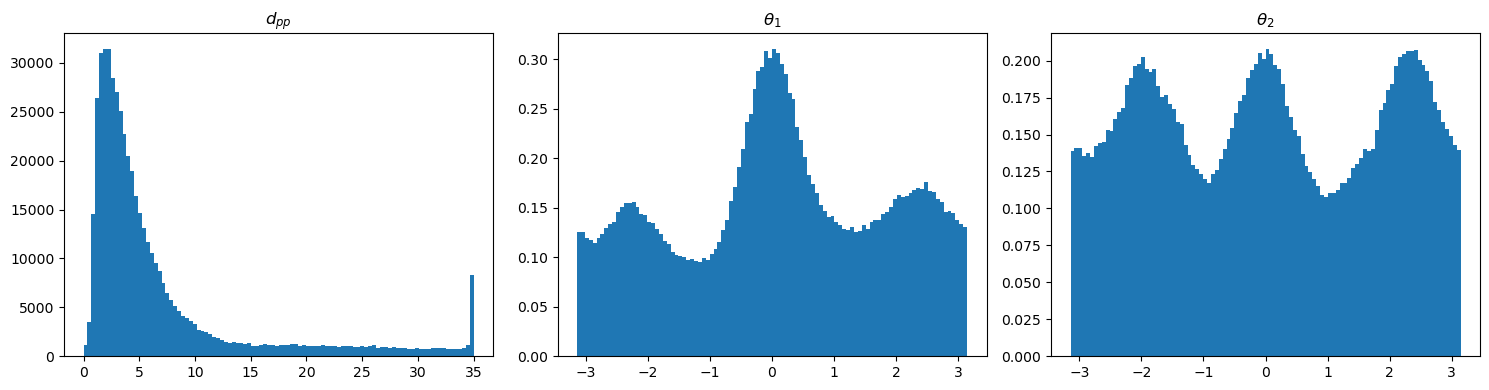

In [64]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].hist(traj_sim[:,0], bins=100)
axs[0].set_title(r'$d_{pp}$')

axs[1].hist(traj_sim[:,1] ,density = True,bins=100)
axs[1].set_title(r"$\theta_1$")

axs[2].hist(traj_sim[:,2],density =True, bins=100)
axs[2].set_title(r"$\theta_2$")

plt.tight_layout()
save_path = "Exploratory_Figures"
os.makedirs(save_path, exist_ok=True)

#plt.savefig(f"{save_path}/Distributions_M=3_K=4_exp2_fight1_50%.png", dpi=300)
plt.show()

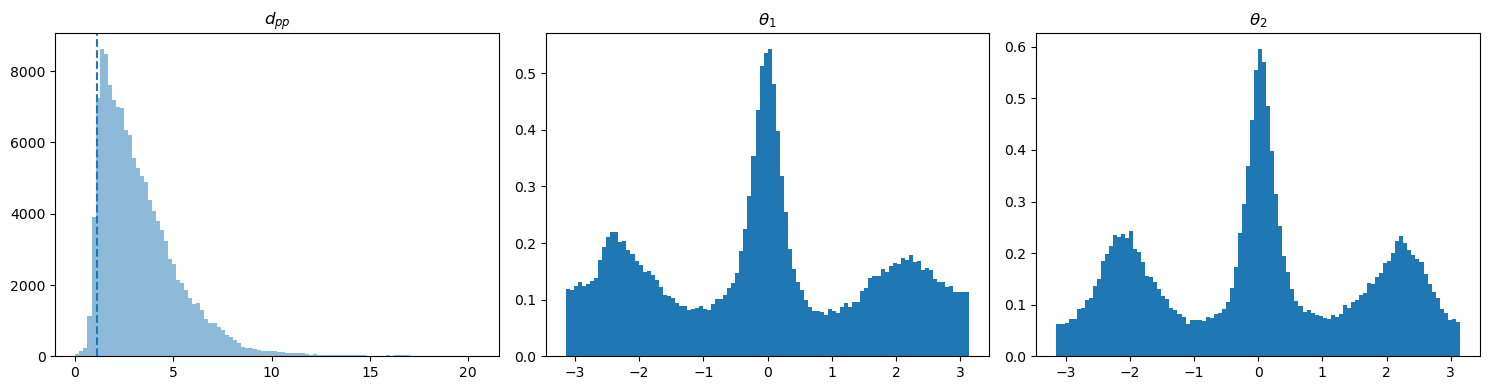

In [417]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))
dpp,theta1,theta2
axs[0].hist(dpp[~np.isnan(dpp)], alpha  = 0.5,bins=100)
axs[0].axvline(x=1.1, linestyle='--')
axs[0].set_title(r'$d_{pp}$')

axs[1].hist(theta1[~np.isnan(theta1)], density=True ,bins=100)
axs[1].set_title(r"$\theta_1$")

axs[2].hist(theta2[~np.isnan(theta2)],density=True ,bins=100)
axs[2].set_title(r"$\theta_2$")

plt.tight_layout()
save_path = "Exploratory_Figures"
os.makedirs(save_path, exist_ok=True)

#plt.savefig(f"{save_path}/Distributions_random_segmentedtrajectories_50%.png", dpi=300)
plt.show()

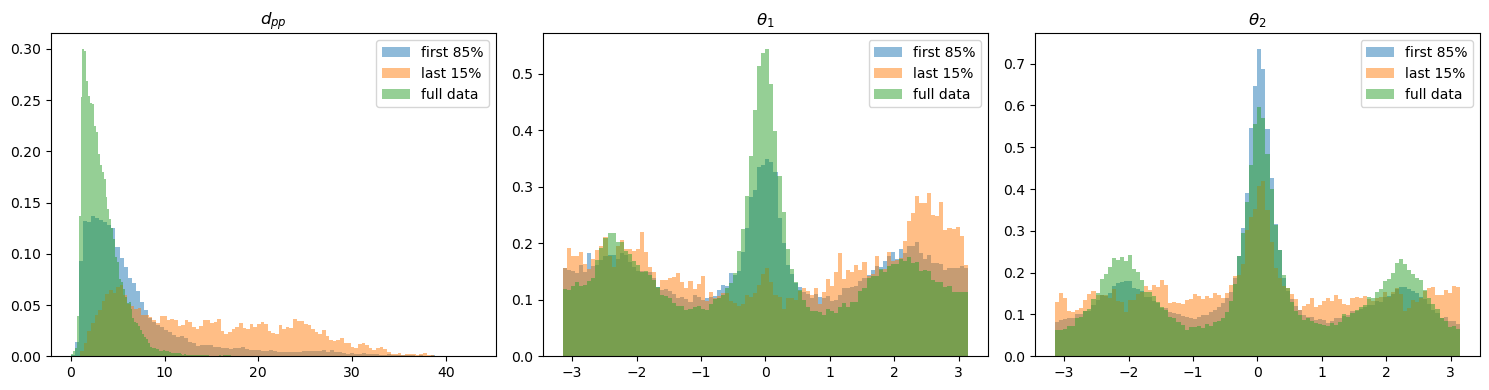

In [168]:
fig, axs = plt.subplots(1, 3, figsize=(15,4))
d_pp_c, theta_i_c, theta_j_c = clean_data(d_pp, theta_i, theta_j)
N = len(d_pp_c)

dpp_85 = d_pp_c[:int(0.85*N)]
dpp_15 = d_pp_c[int(0.85*N):]

thetai_85 = theta_i_c[:int(0.85*N)]
thetai_15 = theta_i_c[int(0.85*N):]

thetaj_85 = theta_j_c[:int(0.85*N)]
thetaj_15 = theta_j_c[int(0.85*N):]

axs[0].hist(dpp_85, bins=100, alpha=0.5, density = True,label='first 85%')
axs[0].hist(dpp_15, bins=100, alpha=0.5,density = True, label='last 15%')
axs[0].hist(d_pp_clean, bins=100, alpha=0.5,density = True, label='full data')
axs[0].set_title(r'$d_{pp}$')
axs[0].legend()

# Theta 1
axs[1].hist(thetai_85, bins=100, alpha=0.5,density = True, label='first 85%')
axs[1].hist(thetai_15, bins=100, alpha=0.5, density = True,label='last 15%')
axs[1].hist(theta_i_clean, bins=100, alpha=0.5, density = True,label='full data')
axs[1].set_title(r"$\theta_1$")
axs[1].legend()

# Theta 2
axs[2].hist(thetaj_85, bins=100, alpha=0.5, density = True,label='first 85%')
axs[2].hist(thetaj_15, bins=100, alpha=0.5,density = True, label='last 15%')
axs[2].hist(theta_j_clean, bins=100, alpha=0.5,density = True, label='full data')
axs[2].set_title(r"$\theta_2$")
axs[2].legend()

plt.tight_layout()
plt.show()

Variation ξ_dpp = 0.480
Variation ξ_θ1 = 1.034
Variation ξ_θ2 = 1.013
Mean ξ_dpp = 0.001
Mean ξ_θ1 = 0.002
Mean ξ_θ2 = 0.001


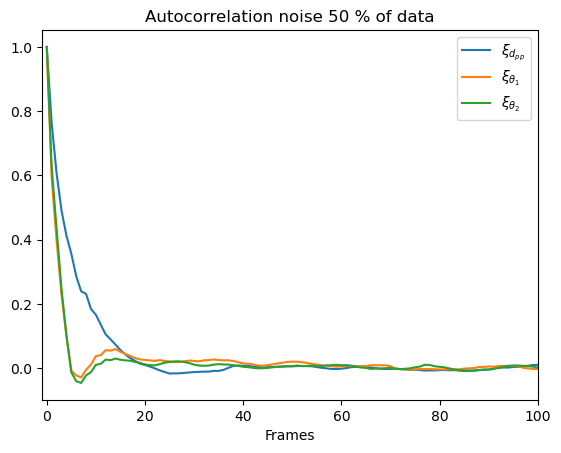

In [40]:
def autocorr(x):
    x = x[np.isfinite(x)] #remove the nans 
    x -= x.mean() #subtract mean
    result = np.correlate(x,x, mode='full') #result = np.correlate(x, x, mode='full')
    result = result[result.size // 2:] # keep only positive values

    return result/result[0]

def Analyse_noise(X,S,dt):
    Diffusion = np.array(S.diffusion_average)
    L = jnp.linalg.cholesky(Diffusion)
    eta_time = np.zeros((len(X[:,1]),3))

    for i in range(len(X[:,1])-1):

        dX = X[i+1,:] - X[i,:]
        F = np.array(S.force_ansatz(X[i:i+1, :])[0])
        R = dX - F*dt
        R[1] = wrap_pi(R[1])
        R[2] = wrap_pi(R[2])

        eta = 1/np.sqrt(2*dt)* np.linalg.inv(L) @ R
        eta_time[i,:] = eta
    dpp_autocorr = autocorr(eta_time[:,0])
    th1_autocorr = autocorr(eta_time[:,1])
    th2_autocorr = autocorr(eta_time[:,2])

    return eta_time,dpp_autocorr,th1_autocorr,th2_autocorr


eta_time,dpp_autocorr,th1_autocorr,th2_autocorr = Analyse_noise(X_50,S_50,dt=0.01)

print(f'Variation ξ_dpp = {np.var(eta_time[:,0]):.3f}')
print(f'Variation ξ_θ1 = {np.var(eta_time[:,1]):.3f}')
print(f'Variation ξ_θ2 = {np.var(eta_time[:,2]):.3f}')

print(f'Mean ξ_dpp = {np.mean(eta_time[:,0]):.3f}')
print(f'Mean ξ_θ1 = {np.mean(eta_time[:,1]):.3f}')
print(f'Mean ξ_θ2 = {np.mean(eta_time[:,2]):.3f}')

plt.plot(dpp_autocorr,label=r'$\xi_{d_{pp}}$')
plt.plot(th1_autocorr,label =r'$\xi_{\theta_1}$')
plt.plot(th2_autocorr,label =r'$\xi_{\theta_2}$')
plt.title(r'Autocorrelation noise 50 % of data')
plt.legend()
plt.xlabel('Frames')
plt.xlim(-1,100)
plt.savefig('Exploratory_Figures/Deterministic_simulation/Autocorrelation_50%.png')



In [13]:
def Simulation_anglesfixed(S, D0, theta1, theta2, dt=0.01, N_steps=5000,
                      early_stop=True, force_tol=1e-4, n_consecutive=20):
    D =  D0
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append([D,theta1,theta2])

        FD = float(S.force_ansatz(np.array([[D, theta1, theta2]]))[0][0])
        D = D + FD * dt

        if early_stop:

            if abs(FD) < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append([D, theta1, theta2])
                break

    return jnp.array(xs)

def Simulation_Dfixed(S,x0,dt,N_steps,D,early_stop= True,force_tol = 1e-4,n_consecutive = 20):
    x = jnp.array(x0)
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append(x)

        drift = S.force_ansatz(x[None, :])[0]
        x = x + drift * dt

        x = x.at[0].set(D if D is not None else x[0])
        x = x.at[1].set(wrap_pi(x[1]))
        x = x.at[2].set(wrap_pi(x[2]))

        if early_stop:
            drift_new = S.force_ansatz(x[None, :])[0]
            force_norm = np.linalg.norm(np.array([drift_new[1], drift_new[2]]))
            if force_norm < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append(x) 
                break

    return jnp.stack(xs)

def Simulation_deterministic(S,x0,dt,N_steps,D,theta1 =None, theta2 = None,early_stop= True,force_tol = 1e-4,n_consecutive = 20):
    x = jnp.array(x0)
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append(x)

        drift = S.force_ansatz(x[None, :])[0]
        x = x + drift * dt

        x = x.at[0].set(D if D is not None else x[0])
        x = x.at[1].set(theta1 if theta1 is not None else wrap_pi(x[1]))
        x = x.at[2].set(theta2 if theta2 is not None else wrap_pi(x[2]))

        if early_stop:
            force_norm = np.linalg.norm(np.array(S.force_ansatz(x[None, :])[0][0]))

            if force_norm < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append(x) 
                break
    return jnp.stack(xs)

#t0 = np.random.randint(0, len(d_pp_clean))
#x0 = [d_pp_clean[t0], theta_i_clean[t0], theta_j_clean[t0]]
#traj_sim = Simulation_deterministic(S, x0, dt=0.01, N_steps=50000,D=2.5,theta1 =None, theta2 = None,early_stop= True,force_tol = 1e-4,n_consecutive = 20)

In [158]:
def endpoint_clustering(all_endpoints):
    D_values = np.unique(all_endpoints[:,0])
    clustered_all = []

    for D in D_values:
        pts = all_endpoints[all_endpoints[:,0] == D]
        
        rounded = np.round(pts[:,1:], 3)
        unique_angles = np.unique(rounded, axis=0)
        
        clustered = np.column_stack([np.full(len(unique_angles), D), unique_angles])
        clustered_all.append(clustered)

    clustered_all = np.vstack(clustered_all)
    return clustered_all

def Find_endpoints(S_model,D_values):
    accept_rate = []
    all_endpoints =[]


    for d_sim in D_values:
        startpoints = []
        accepted_trajs = []
        length = np.linspace(-np.pi, np.pi, 35,endpoint = False)
        for theta_i0 in length:
            for theta_j0 in length:
                x0 = [d_sim, theta_i0, theta_j0]
                #x0 = [d_sim, np.random.uniform(-np.pi, np.pi),np.random.uniform(-np.pi, np.pi)]
                traj_sim = Simulation_Dfixed(S_model, x0, dt=0.01, N_steps=5000,D=d_sim,early_stop= True,force_tol = 1e-4,n_consecutive = 20)
                if np.linalg.norm(S_model.force_ansatz(traj_sim[-1][None, :])[0][1:]) < 1e-4:
                    accepted_trajs.append(traj_sim)
                    startpoints.append(traj_sim[0])
        accept_rate.append(len(accepted_trajs) / (len(length) * len(length)))
        

        endpoints = np.array([traj[-1] for traj in accepted_trajs])
        all_endpoints.append(endpoints)
        startpoints = np.array(startpoints)
        
        plt.figure()
        plt.scatter((startpoints[:,1]), startpoints[:,2], label ='start point')
        plt.scatter((endpoints[:,1]), endpoints[:,2],color = 'r',label = 'end point')
        plt.xlabel(r'$\theta_1$')
        plt.ylabel(r'$\theta_2$')
        plt.title(f'End point deterministic simulation, fixed d={d_sim:.1f}')
        plt.legend()
        plt.savefig(f'Exploratory_Figures/Deterministic_simulation/half_End_point_D={d_sim:.1f}.png')
        plt.close()

        plt.figure()
        plt.hist2d(endpoints[:,1], endpoints[:,2], bins=30,range=[[-np.pi, np.pi], [-np.pi, np.pi]])
        plt.colorbar(label='count')
        plt.xlabel(r'$\theta_1$')
        plt.ylabel(r'$\theta_2$')
        plt.title(f'Endpoint density, d ={d_sim:.1f} ')
        plt.savefig(f'Exploratory_Figures/Deterministic_simulation/half_Heatmap_endpoint_D={d_sim:.1f}.png')
        plt.close()

    all_endpoints = np.vstack(all_endpoints)
    clustered_all = endpoint_clustering(all_endpoints)
    print(accept_rate)
    return clustered_all, accept_rate

#D_values = np.linspace(0.5,4,50)
#D_values = np.concatenate([np.linspace(0.5, 4.0, 35, endpoint=False),np.linspace(4.0, 6.0, 10, endpoint=False),np.linspace(6.0, 8.0, )])
D_values = np.linspace(0.5,4.5,80)
clustered_endpoints, accept_rate = Find_endpoints(S_half,D_values)
np.savetxt("endpoints_half.csv",clustered_endpoints,delimiter=",",header="d,theta1,theta2",comments="")

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.7844897959183673, 1.0, 1.0, 1.0, 1.0, 0.9991836734693877, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9991836734693877, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.6179591836734694, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [43]:
np.mean([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.7844897959183673, 1.0, 1.0, 1.0, 1.0, 0.9991836734693877, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9991836734693877, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.6179591836734694, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
)

np.float64(0.9925102040816327)

[[ 2.93037963e+00 -2.17300010e+00 -1.56000003e-01]
 [ 2.93037963e+00 -1.20700002e+00 -8.60000029e-02]
 [ 2.93037963e+00  8.00000038e-03 -2.55800009e+00]
 [ 2.93037963e+00  2.47000003e+00  1.49000004e-01]
 [ 2.98101258e+00 -2.14299989e+00 -1.67999998e-01]
 [ 2.98101258e+00 -7.96999991e-01  4.89999987e-02]
 [ 2.98101258e+00 -7.96000004e-01  4.89999987e-02]
 [ 2.98101258e+00  6.00000005e-03 -2.55299997e+00]
 [ 2.98101258e+00  1.52900004e+00  1.88499999e+00]
 [ 2.98101258e+00  2.43799996e+00  1.57000005e-01]
 [ 3.03164554e+00 -2.10100007e+00 -1.84000000e-01]
 [ 3.03164554e+00 -5.50999999e-01  4.89999987e-02]
 [ 3.03164554e+00 -5.50000012e-01  4.89999987e-02]
 [ 3.03164554e+00  3.00000003e-03 -2.54800010e+00]
 [ 3.03164554e+00  1.55799997e+00  1.84300005e+00]
 [ 3.03164554e+00  2.40100002e+00  1.65000007e-01]
 [ 3.08227849e+00 -2.03299999e+00 -2.07000002e-01]
 [ 3.08227849e+00 -2.03200006e+00 -2.07000002e-01]
 [ 3.08227849e+00 -4.37999994e-01  3.99999991e-02]
 [ 3.08227849e+00  1.00000005e-

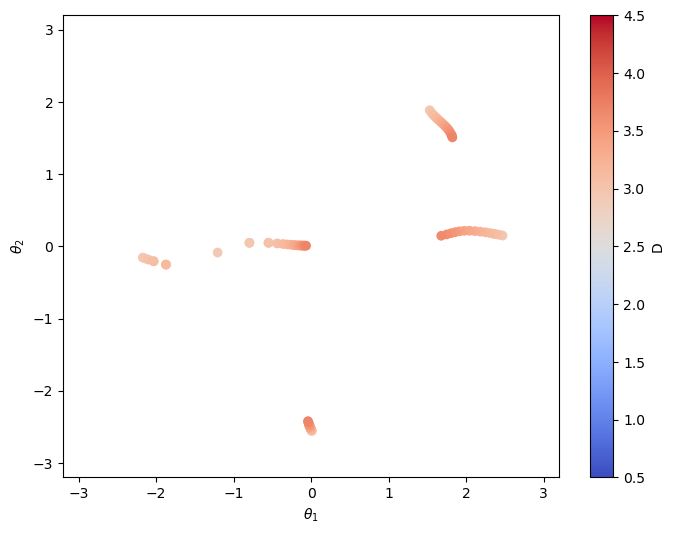

In [49]:
clustered_all = pd.read_csv("endpoints_4.5.csv").values
D_values = np.unique(clustered_all[:,0])

D_min = 2.9
D_max = 3.7

mask = (clustered_all[:,0] >= D_min) & (clustered_all[:,0] <= D_max)
data_filtered = clustered_all[mask]
print(data_filtered)


plt.figure(figsize=(8,6))
sc = plt.scatter(data_filtered[:,1],
    data_filtered[:,2],
    c=data_filtered[:,0],
                 cmap='coolwarm',vmin=D_values.min(),  
    vmax=D_values.max())

cbar = plt.colorbar(sc)
cbar.set_label("D")

plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.xlim(-3.2,3.2)
plt.ylim(-3.2,3.2)
#plt.savefig(f'Exploratory_Figures/Deterministic_simulation/Endpoint_distribution_rangeto4.5_lowD_filter.png')
plt.show()


In [150]:
def symmetry_error_components(S, D, n_samples=200):
    err_D = []
    err_th1 = []
    err_th2 = []

    for _ in range(n_samples):
        theta1 = np.random.uniform(-np.pi, np.pi)
        theta2 = np.random.uniform(-np.pi, np.pi)

        x = np.array([[D, theta1, theta2]])
        x_ref = np.array([[D, -theta1, -theta2]])

        F = np.array(S.force_ansatz(x)[0])
        F_ref = np.array(S.force_ansatz(x_ref)[0])

        # D-component should be even
        err_D.append(abs(F[0] - F_ref[0]))

        # angular components should be odd
        err_th1.append(abs(F[1] + F_ref[1]))
        err_th2.append(abs(F[2] + F_ref[2]))

    return np.mean(err_D), np.mean(err_th1), np.mean(err_th2)

print(symmetry_error_components(S, D=2.5))

(np.float32(0.9491756), np.float32(1.8329698), np.float32(2.1583655))


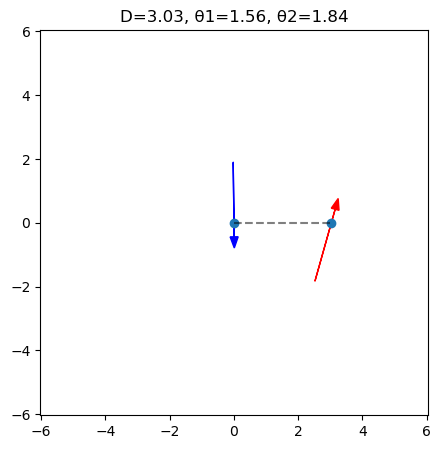

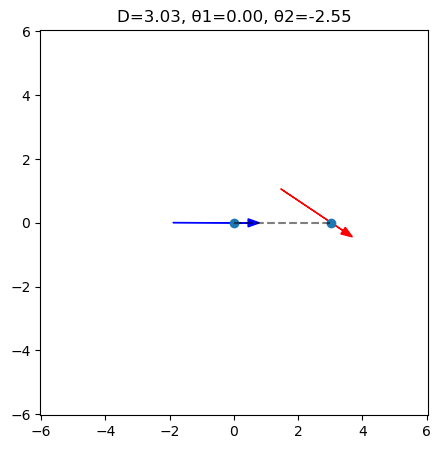

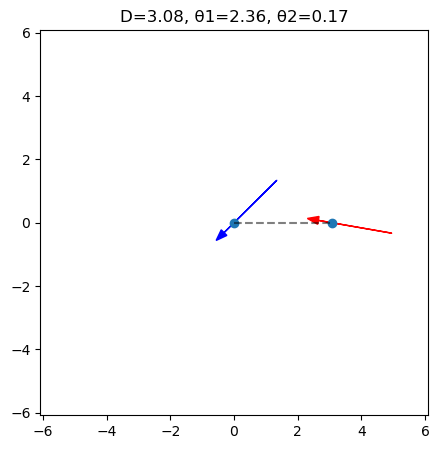

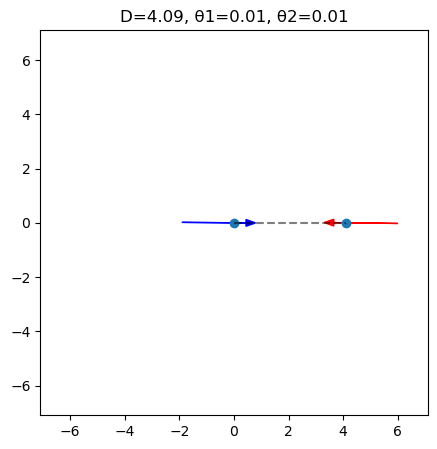

In [41]:
def plot_two_agents(D, theta1, theta2):
    L_head = 0.79
    L_tail = 1.90

    x1, y1 = 0, 0
    x2, y2 = D, 0
    theta1_abs = wrap_pi(-theta1)
    theta2_abs = wrap_pi(np.pi - theta2)

    d1 = np.array([np.cos(theta1_abs), np.sin(theta1_abs)])
    d2 = np.array([np.cos(theta2_abs), np.sin(theta2_abs)])

    tail1 = np.array([x1, y1]) - L_tail * d1
    tail2 = np.array([x2, y2]) - L_tail * d2


    vec1 = (L_head + L_tail) * d1
    vec2 = (L_head + L_tail) * d2

    plt.figure(figsize=(5,5))
    plt.arrow(*tail1, *vec1,
              head_width=0.25, head_length=0.35,
              length_includes_head=True, color='blue')

    plt.arrow(*tail2, *vec2,
              head_width=0.25, head_length=0.35,
              length_includes_head=True, color='red')

    plt.scatter([x1, x2], [y1, y2], color='tab:blue')
    plt.plot([x1, x2], [y1, y2], 'k--', alpha=0.5)

    lim = D + 3
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)

    plt.title(f"D={D:.2f}, θ1={theta1:.2f}, θ2={theta2:.2f}")
    plt.show()

plot_two_agents(3.03164554e+00 , 1.55799997e+00  ,1.84300005e+00)
plot_two_agents(3.03164554e+00,  3.00000003e-03, -2.54800010e+00)
plot_two_agents(3.08227849e+00 , 2.35700011e+00 , 1.73999995e-01)
plot_two_agents(4.09493685e+00 , 8.00000038e-03 , 1.30000003e-02)


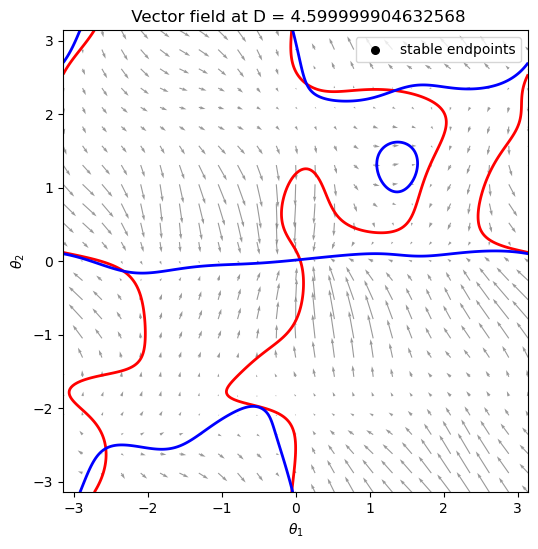

In [122]:
D_value = 4.599999904632568359e+00
theta_vals = np.linspace(-np.pi, np.pi, 300)
th1, th2 = np.meshgrid(theta_vals, theta_vals)

d_dt, th1_dt, th2_dt = F(
    np.full(th1.size, D_value),
    th1.ravel(),
    th2.ravel()
)

th1_dt = th1_dt.reshape(th1.shape)
th2_dt = th2_dt.reshape(th2.shape)

theta_vals_q = np.linspace(-np.pi, np.pi, 25)
th1_q, th2_q = np.meshgrid(theta_vals_q, theta_vals_q)

_, th1_dt_q, th2_dt_q = F(np.full(th1_q.size, D_value),th1_q.ravel(),th2_q.ravel())

plt.figure(figsize=(6,6))
plt.contour(th1, th2, th1_dt, levels=[0], colors='red', linewidths=2)
plt.contour(th1, th2, th2_dt, levels=[0], colors='blue', linewidths=2)
plt.quiver(th1_q, th2_q, th1_dt_q, th2_dt_q, color='gray', alpha=0.8)
mask = np.isclose(clustered_all[:, 0], D_value)
endpoints_D = clustered_all[mask]
plt.scatter(endpoints_D[:,1], endpoints_D[:,2], c='k', s=30, label='stable endpoints')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title(f' Vector field at D = {D_value}')
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.legend()
plt.show()

In [125]:
Theta1 = [2.2]
Theta2 = [0.8]
accept_rate = []
all_endpoints =[]
Iterations = 100
for k in range(len(Theta1)):
    accepted_trajs = []
    for i in range(Iterations):
        t0 = np.random.randint(0, len(d_pp_clean))
        #x0 = [d_sim, theta_i_clean[t0], theta_j_clean[t0]]
        x0 = [np.random.uniform(0,10), Theta1[k],Theta2[k]]
        traj_sim = Simulation_deterministic(S, x0, dt=0.01, N_steps=5000,D=None,theta1 =Theta1[k], theta2 = Theta2[k])
        if np.linalg.norm(S.force_ansatz(traj_sim[-1][None, :])[0][0]) < 1e-4:
            accepted_trajs.append(traj_sim)
    accept_rate.append(len(accepted_trajs) / Iterations)
    print('for th1=',Theta1[k],'and th2 =,',Theta2[k] ,'accept rate = ',accept_rate)

    endpoints = np.array([traj[-1] for traj in accepted_trajs])
    startpoint = np.array([traj[0] for traj in accepted_trajs])
    all_endpoints.append(endpoints)
    
    plt.figure()
    plt.scatter((startpoint[:,0]), endpoints[:,0], label ='start point')
    plt.xlabel(r'initial $D$')
    plt.ylabel(r'final $D$')
    plt.title(f'End point deterministic simulation, fixed th1={Theta1[k]:.1f} and {Theta2[k]}')
    plt.legend()
    plt.savefig(f'Exploratory_Figures/Deterministic_simulation/End_point_th1={Theta1[k]:.1f} and {Theta2[k]}.png')
    plt.close()

    plt.figure()
    plt.hist(endpoints[:,0], bins=30,range=[0,20])
    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')
    plt.title(f'Endpoint density, fixed th1={Theta1[k]:.1f} and {Theta2[k]} ')
    plt.savefig(f'Exploratory_Figures/Deterministic_simulation/Histogram_End_point_th1={Theta1[k]:.1f} and {Theta2[k]}.png')
    plt.close()
all_endpoints = np.vstack(all_endpoints)

for th1= 2.2 and th2 =, 0.8 accept rate =  [1.0]


In [ ]:
import numpy as np

save_dict = {
    "force_coefficients": np.array(S.force_coefficients),
    "diffusion": np.array(S.diffusion_average),
    "basis_names": S.force_basis_names,
    "stderr": np.array(S.force_coefficients_stderr),
}

with open("sfi_model_segmented_M3.pkl", "wb") as f:
    pickle.dump(save_dict, f)
print("Number of descriptors:", len(descriptor))
for i, d in enumerate(descriptor):
    print(i, d)